In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravrawat99/loan-payback-train/train.csv
/kaggle/input/datasets/gauravrawat99/loan-payback-test/test.csv


In [2]:
import pandas as pd
train=pd.read_csv('/kaggle/input/datasets/gauravrawat99/loan-payback-train/train.csv')
train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


### EDA

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [4]:
train.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [5]:
#Value counts for categorical cols
cat_cols = ['gender', 'marital_status', 'education_level',
            'employment_status', 'loan_purpose', 'grade_subgrade']

for col in cat_cols:
    print(f"\n===== {col} =====")
    
    vc = train[col].value_counts(dropna=False)
    
    for category, count in vc.items():
        print(f"{category} : {count}")


===== gender =====
Female : 306175
Male : 284091
Other : 3728

===== marital_status =====
Single : 288843
Married : 277239
Divorced : 21312
Widowed : 6600

===== education_level =====
Bachelor's : 279606
High School : 183592
Master's : 93097
Other : 26677
PhD : 11022

===== employment_status =====
Employed : 450645
Unemployed : 62485
Self-employed : 52480
Retired : 16453
Student : 11931

===== loan_purpose =====
Debt consolidation : 324695
Other : 63874
Car : 58108
Home : 44118
Education : 36641
Business : 35303
Medical : 22806
Vacation : 8449

===== grade_subgrade =====
C3 : 58695
C4 : 55957
C2 : 54443
C1 : 53363
C5 : 53317
D1 : 37029
D3 : 36694
D4 : 35097
D2 : 34432
D5 : 32101
B2 : 15167
B1 : 14344
B5 : 13937
B3 : 13926
B4 : 13877
E4 : 8036
E3 : 7075
E1 : 6891
E2 : 6372
E5 : 6084
F5 : 5947
F4 : 5535
F1 : 5534
F2 : 5203
F3 : 5082
A5 : 2471
A3 : 2066
A2 : 2018
A4 : 1701
A1 : 1600


In [6]:
#Removing extra quotes from cat cols
cat_cols=train.select_dtypes(include=object).columns

for col in cat_cols:
    train[col]=(train[col].astype(str).str.replace("'", "", regex=False).str.replace('"','',regex=False).str.strip())

In [7]:
# #Mapping of gender, marital_status cols to numerical values
# train['gender'] = train['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

# train['marital_status'] = train['marital_status'].map({'Single':0,'Married':1,"Divorced":2, 'Widowed':3})

In [8]:
train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Masters,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelors,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelors,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelors,Employed,Debt consolidation,B2,1.0


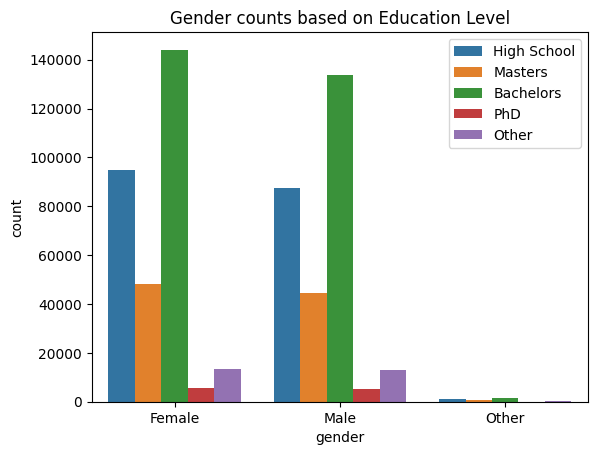

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=train, x='gender', hue='education_level')
plt.legend()
plt.title('Gender counts based on Education Level')
plt.show()

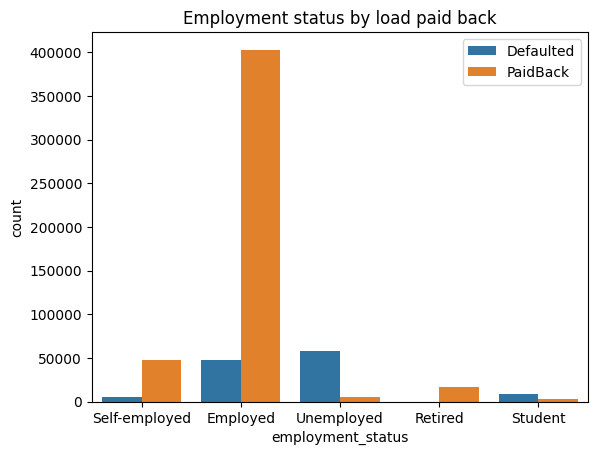

employment_status  loan_paid_back
Employed           0.0                47703
                   1.0               402942
Retired            0.0                   46
                   1.0                16407
Self-employed      0.0                 5329
                   1.0                47151
Student            0.0                 8787
                   1.0                 3144
Unemployed         0.0                57635
                   1.0                 4850
Name: loan_paid_back, dtype: int64

In [10]:
sns.countplot(data=train, x='employment_status', hue='loan_paid_back')
plt.legend(['Defaulted', 'PaidBack'])
plt.title("Employment status by load paid back")
plt.show()

train.groupby(['employment_status', 'loan_paid_back'])['loan_paid_back'].count()

education_level  employment_status
Bachelors        Employed             187490
                 Retired                7439
                 Self-employed         21866
                 Student                1439
                 Unemployed             2345
High School      Employed             126055
                 Retired                5479
                 Self-employed         14645
                 Student                1022
                 Unemployed             1453
Masters          Employed              63576
                 Retired                2313
                 Self-employed          7575
                 Student                 493
                 Unemployed              739
Other            Employed              18158
                 Retired                 755
                 Self-employed          2147
                 Student                 131
                 Unemployed              225
PhD              Employed               7663
                 Ret

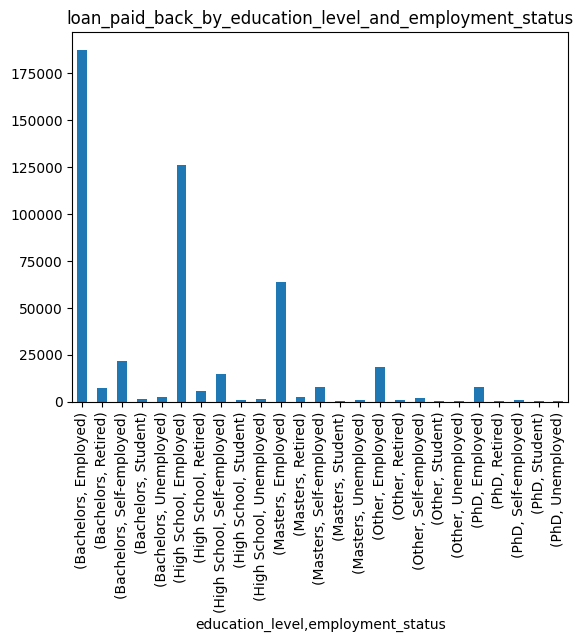

In [11]:
#Loan amount paid of education_level by employment_status
group_loan_paid_back_by_education_level_and_employment_status=train[train['loan_paid_back'] == 1.0].groupby(['education_level', 'employment_status'])['loan_paid_back'].count()
group_loan_paid_back_by_education_level_and_employment_status.plot(kind='bar')
plt.title('loan_paid_back_by_education_level_and_employment_status')
print(group_loan_paid_back_by_education_level_and_employment_status)

In [12]:
pip install xgboost catboost

Note: you may need to restart the kernel to use updated packages.


## Feature Engineering

In [13]:
train['loan_to_amount'] = train['loan_amount']/train['annual_income']
train['emi_proxy'] = train['loan_amount'] * train['interest_rate']
train['income_after_loan'] = train['annual_income'] - train['loan_amount']

train['credit_income_ratio'] = train['credit_score'] / train['annual_income']
train['credit_dti_interaction'] = train['credit_score'] * train['debt_to_income_ratio']

train['interest_to_loan'] = train['interest_rate'] / train['loan_amount']
train['interest_income_ratio'] = train['interest_rate'] / train['annual_income']

#Working on grade col
train['grade']=train['grade_subgrade'].str[0]
train['subgrade_num']=train['grade_subgrade'].str[1:].astype(int)
train['grade_numeric'] = train['grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
train['grade_risk']=train['grade_numeric'] * train['subgrade_num']

#Working on adding cat col
train['edu_emp_combo'] = (train['education_level'] + "_" + train['employment_status'])
train['purpose_grade_combo'] = (train['loan_purpose'] + "_" + train['grade'])

train['high_dti_flag'] = (train['debt_to_income_ratio'] > 0.4).astype(int)
train['low_credit_flag'] = (train['credit_score'] < 600).astype(int)
train['high_loan_flag'] = (train['loan_amount'] > train['annual_income'] * 0.5).astype(int)

train['dti_loan_interaction'] = train['debt_to_income_ratio'] * train['loan_amount']
train['credit_loan_interaction'] = train['credit_score'] * train['loan_amount']

train['income_bin'] = pd.qcut(train['annual_income'], 5, labels=False)
train['credit_bin'] = pd.qcut(train['credit_score'], 5, labels=False)

In [14]:
train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,...,grade_risk,edu_emp_combo,purpose_grade_combo,high_dti_flag,low_credit_flag,high_loan_flag,dti_loan_interaction,credit_loan_interaction,income_bin,credit_bin
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,...,9,High School_Self-employed,Other_C,0,0,0,212.38728,1860917.12,1,4
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Masters,Employed,...,12,Masters_Employed,Debt consolidation_D,0,0,0,762.45460,2921211.60,0,0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,...,15,High School_Employed,Debt consolidation_C,0,0,0,1649.49955,11801574.10,2,2
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,...,6,High School_Employed,Debt consolidation_F,0,1,0,304.36120,2495761.84,2,0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,...,4,High School_Employed,Other_D,0,0,0,645.77479,8102645.95,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,...,9,High School_Employed,Business_C,0,0,1,3185.67224,14733734.11,0,3
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelors,Employed,...,30,Bachelors_Employed,Debt consolidation_F,0,1,0,342.01020,1820797.16,1,0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelors,Employed,...,3,Bachelors_Employed,Debt consolidation_C,0,0,0,66.90744,627257.25,2,2
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelors,Employed,...,4,Bachelors_Employed,Debt consolidation_B,0,0,0,1091.45680,12054896.00,4,4


## Catboost classifier now

In [21]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

X=train.drop(['id', 'loan_paid_back'], axis=1)
y=train['loan_paid_back']

cat_cols=train.select_dtypes(include=object).columns.tolist()

X_train, X_val, y_train, y_val=train_test_split(X, y, test_size=0.15, random_state=42)

train_pool=Pool(X_train, y_train, cat_features=cat_cols)
val_pool=Pool(X_val, y_val, cat_features=cat_cols)
'''
param_grid={'depth':[4,5,6,7,8],
           'learning_rate':[0.01,0.02,0.03,0.04,0.05],
           'iterations':[1000,1500,2000,2500,3000,4000],
           'l2_leaf_reg':[1,2,3,4,5]}

model=CatBoostClassifier(eval_metric='AUC', thread_count=-1, random_seed=42, verbose=False)

grid_result=model.grid_search(param_grid, train_pool, cv=5, stratified=True)

model.get_params()'''

model = CatBoostClassifier(
    depth=6,
    learning_rate=0.02,
    l2_leaf_reg=3,
    iterations=5000,
    eval_metric='AUC',
    early_stopping_rounds=200,
    thread_count=-1,
    random_seed=42,
    verbose=200
)

model.fit(train_pool, eval_set=val_pool)

0:	test: 0.8999032	best: 0.8999032 (0)	total: 680ms	remaining: 56m 39s
200:	test: 0.9163140	best: 0.9163140 (200)	total: 2m 8s	remaining: 51m 3s
400:	test: 0.9177335	best: 0.9177335 (400)	total: 4m 21s	remaining: 49m 57s
600:	test: 0.9184322	best: 0.9184322 (600)	total: 6m 33s	remaining: 48m
800:	test: 0.9192862	best: 0.9192862 (800)	total: 8m 49s	remaining: 46m 14s
1000:	test: 0.9199525	best: 0.9199525 (1000)	total: 11m 4s	remaining: 44m 13s
1200:	test: 0.9204626	best: 0.9204626 (1200)	total: 13m 23s	remaining: 42m 21s
1400:	test: 0.9209306	best: 0.9209306 (1400)	total: 15m 39s	remaining: 40m 14s
1600:	test: 0.9213083	best: 0.9213083 (1600)	total: 17m 58s	remaining: 38m 8s
1800:	test: 0.9216481	best: 0.9216481 (1800)	total: 20m 16s	remaining: 36m
2000:	test: 0.9219283	best: 0.9219283 (2000)	total: 22m 35s	remaining: 33m 50s
2200:	test: 0.9222017	best: 0.9222017 (2200)	total: 24m 53s	remaining: 31m 39s
2400:	test: 0.9223872	best: 0.9223878 (2399)	total: 27m 12s	remaining: 29m 26s
2600:

CatBoostClassifier(depth=6, early_stopping_rounds=200, eval_metric='AUC', iterations=5000, l2_leaf_reg=3, learning_rate=0.02, random_seed=42, verbose=200)

In [24]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

val_pred=model.predict(val_pool)
val_pred_prob=model.predict_proba(val_pool)[:,1]

print('ROC-AUC score: ', roc_auc_score(y_val, val_pred_prob))
print('Confusion matrix:\n', confusion_matrix(y_val, val_pred))
print('Classification Report:\n', classification_report(y_val, val_pred))

ROC-AUC score:  0.9238251447568802
Confusion matrix:
 [[11129  6947]
 [ 1446 69578]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.62      0.73     18076
         1.0       0.91      0.98      0.94     71024

    accuracy                           0.91     89100
   macro avg       0.90      0.80      0.83     89100
weighted avg       0.90      0.91      0.90     89100



Index(['Feature Id', 'Importances'], dtype='object')


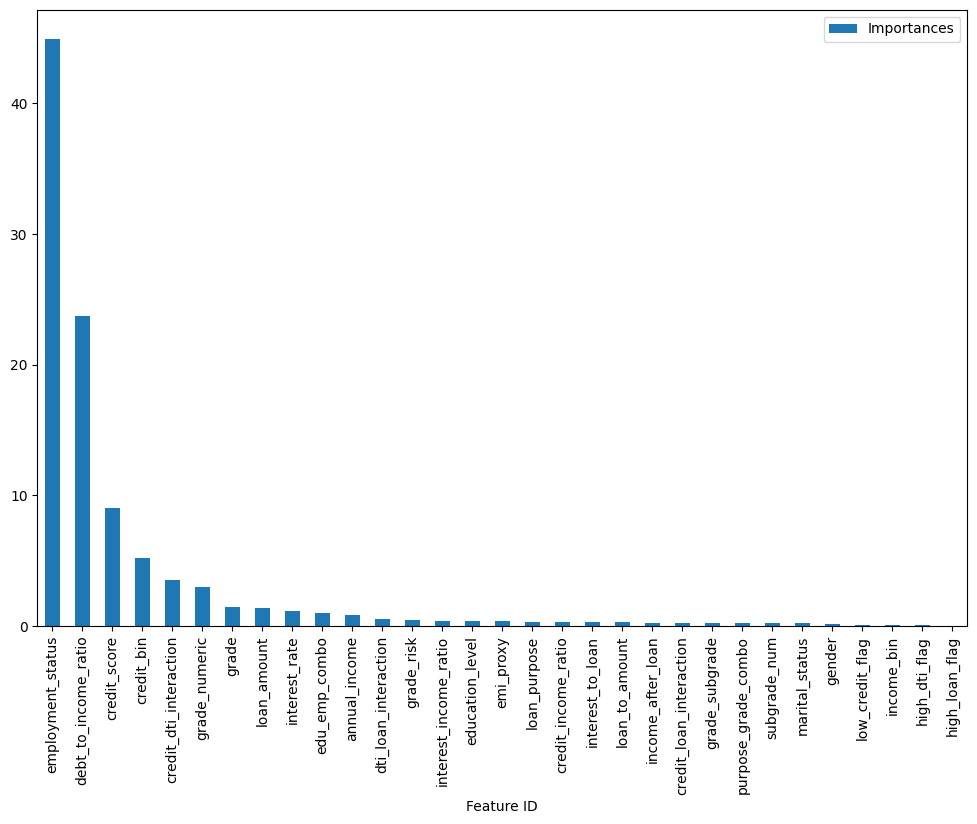

In [29]:
fi=model.get_feature_importance(prettified=True)
print(fi.columns)

# Rename generically
fi.columns = ['Feature ID', 'Importances']

fi = fi.sort_values('Importances', ascending=False)

import matplotlib.pyplot as plt

fi.plot(
    x='Feature ID',
    y='Importances',
    kind='bar',
    figsize=(12,8)
)
plt.show()

## On Test data and file submission

In [32]:
test=pd.read_csv("/kaggle/input/datasets/gauravrawat99/loan-payback-test/test.csv")

test_ID = test['id']

test['loan_to_amount'] = test['loan_amount']/test['annual_income']
test['emi_proxy'] = test['loan_amount'] * test['interest_rate']
test['income_after_loan'] = test['annual_income'] - test['loan_amount']

test['credit_income_ratio'] = test['credit_score'] / test['annual_income']
test['credit_dti_interaction'] = test['credit_score'] * test['debt_to_income_ratio']

test['interest_to_loan'] = test['interest_rate'] / test['loan_amount']
test['interest_income_ratio'] = test['interest_rate'] / test['annual_income']

#Working on grade col
test['grade']=test['grade_subgrade'].str[0]
test['subgrade_num']=test['grade_subgrade'].str[1:].astype(int)
test['grade_numeric'] = test['grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
test['grade_risk']=test['grade_numeric'] * test['subgrade_num']

#Working on adding cat col
test['edu_emp_combo'] = (test['education_level'] + "_" + test['employment_status'])
test['purpose_grade_combo'] = (test['loan_purpose'] + "_" + test['grade'])

test['high_dti_flag'] = (test['debt_to_income_ratio'] > 0.4).astype(int)
test['low_credit_flag'] = (test['credit_score'] < 600).astype(int)
test['high_loan_flag'] = (test['loan_amount'] > test['annual_income'] * 0.5).astype(int)

test['dti_loan_interaction'] = test['debt_to_income_ratio'] * test['loan_amount']
test['credit_loan_interaction'] = test['credit_score'] * test['loan_amount']

test['income_bin'] = pd.qcut(test['annual_income'], 5, labels=False)
test['credit_bin'] = pd.qcut(test['credit_score'], 5, labels=False)

In [33]:
test

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,...,grade_risk,edu_emp_combo,purpose_grade_combo,high_dti_flag,low_credit_flag,high_loan_flag,dti_loan_interaction,credit_loan_interaction,income_bin,credit_bin
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,...,20,High School_Employed,Other_D,0,0,0,561.60958,7174848.92,1,0
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,...,3,Master's_Employed,Other_C,0,0,0,1440.77925,11340327.00,2,4
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,...,4,Bachelor's_Employed,Debt consolidation_D,0,0,0,1393.28247,2319606.51,3,0
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,...,9,Bachelor's_Employed,Debt consolidation_C,0,0,0,723.17300,4411355.30,1,2
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,...,3,PhD_Employed,Business_C,0,0,1,1433.44809,12175460.32,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,...,4,Bachelor's_Employed,Debt consolidation_B,0,0,0,2019.87200,22099776.00,4,4
254565,848559,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,...,16,High School_Employed,Debt consolidation_D,0,0,0,1845.87403,12860265.22,2,0
254566,848560,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,...,12,Master's_Employed,Debt consolidation_C,0,0,1,2533.20480,18946260.90,0,3
254567,848561,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,...,6,Bachelor's_Employed,Business_C,0,0,0,1044.09184,8208339.04,1,4


In [35]:
from catboost import Pool

# Ensure test has same column order as training
test = test[X.columns]

# Create Pool with categorical features
test_pool = Pool(
    data=test,
    cat_features=cat_cols
)

# Predict probabilities
test_probs = model.predict_proba(test_pool)[:, 1]

In [36]:
print(test_probs)

[0.93676532 0.98414354 0.41372591 ... 0.96407868 0.98113625 0.92463486]


In [38]:
import pandas as pd

submission = pd.DataFrame({
    "id": test_ID,
    "loan_paid_back": test_probs
})

submission.to_csv("submission.csv", index=False)

print("submission.csv saved!")
print(f"Shape           : {submission.shape}")
print(f"Mean prediction : {submission['loan_paid_back'].mean():.5f}")
print(f"Std  prediction : {submission['loan_paid_back'].std():.5f}")

display(submission.head(20))
print(submission.isnull().sum())

submission.csv saved!
Shape           : (254569, 2)
Mean prediction : 0.80086
Std  prediction : 0.29671


,id,loan_paid_back
0,593994,0.936765
1,593995,0.984144
2,593996,0.413726
3,593997,0.930502
4,593998,0.963439
5,593999,0.974556
6,594000,0.985542
7,594001,0.969187
8,594002,0.932510
9,594003,0.001335


id                0
loan_paid_back    0
dtype: int64
